## Handbook of Pulsar Astronomy
Lorimer, D. R. ; Kramer, M.
https://ui.adsabs.harvard.edu/abs/2004hpa..book.....L/abstract

For time-domain studies, useful quantities are the \colorbox{yellow}{signal to noise} ratio,
$S/N$, and chi-square statistic, $\chi^{2}$, of a pulse profile $p_{i}$ with $n_{\text{bins}}$ bins
defined by:

$$
S/N=\frac{1}{\sigma_{\text{p}}\sqrt{W_{\text{eq}}}}\sum_{i = 1}^{n_{\text{bins}}}(p_{i}-\bar{p}) \quad \text{and} \quad 
\chi^{2}=\frac{1}{\sigma_{\text{p}}^{2}}\sum_{i = 1}^{n_{\text{bins}}}(p_{i}-\bar{p})^{2},
$$


where $\bar{p}$ and $\sigma_{\text{p}}$ are the off-pulse mean and standard deviation and $W_{\text{eq}}$
is the equivalent width in bins. For further details, see Section 7.1.1.

### 7.1.1.1 Signal to noise ratio (SNR)

The most commonly - used measure of profile significance is the signal to noise ratio, $S/N$, usually defined as follows:

$$
S/N=\frac{1}{\sigma_{\text{p}}\sqrt{W_{\text{eq}}}}\sum_{i = 1}^{n_{\text{bins}}}(p_{i}-\bar{p}), \quad (7.1)
$$

where $W_{\text{eq}}$ is the equivalent width (in bins) of a top - hat pulse with the same area and peak height as the observed profile. As defined in Chapter 3, $W_{\text{eq}}$ is simply the area under the observed pulse divided by its peak height. Assuming the noise distribution follows Gaussian statistics, the probability of obtaining a profile with a particular $S/N$ by chance

$$
\text{Prob}(>S/N)=\frac{1}{\sqrt{2\pi}}\int_{S/N}^{\infty}e^{-x^{2}/2}dx=\frac{1}{2}\left[1 - \text{erf}\left(\frac{S/N}{\sqrt{2}}\right)\right], \quad (7.2)
$$

where the error function $\text{erf}(x)=(2/\sqrt{\pi})\int_{0}^{x}\exp(-x^{2})dx$ can be solved numerically (see, for example, Press et al. (1992)).

##### 2025 / 04 /05 --- DejiangYin--- yin dot dj at qq dot com

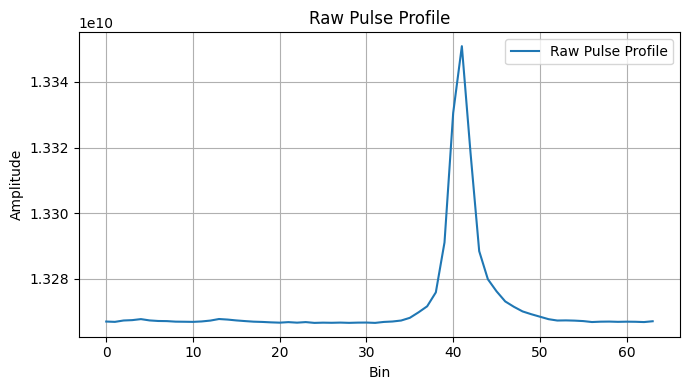

In [35]:
import numpy as np
import matplotlib.pyplot as plt
# Set the file path (replace it with your local path)
filepath = r"D:\FAST_document\data_process\1622-0315\SNR_sensitivity\gaussians_PSR_1622-0315.pfd.bestprof"
# Read the content of the file
with open(filepath, 'r') as f:
    lines = f.readlines()
# Extract the profile data (There are 128 lines of pulse profile data after "#####")
profile_data = []
start_reading = False
for line in lines:
    if line.strip().startswith("#####"):
        start_reading = True
        continue
    if start_reading:
        idx, val = line.strip().split()
        profile_data.append(float(val))

# Convert to a numpy array
profile = np.array(profile_data)
nbins = len(profile)
# Visualize the raw pulse profile data
plt.figure(figsize=(7, 4))
plt.plot(profile, label='Raw Pulse Profile')
plt.title("Raw Pulse Profile")
plt.xlabel("Bin")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Equivalent Width (Weq): 3.60 bins
S/N: 537.34


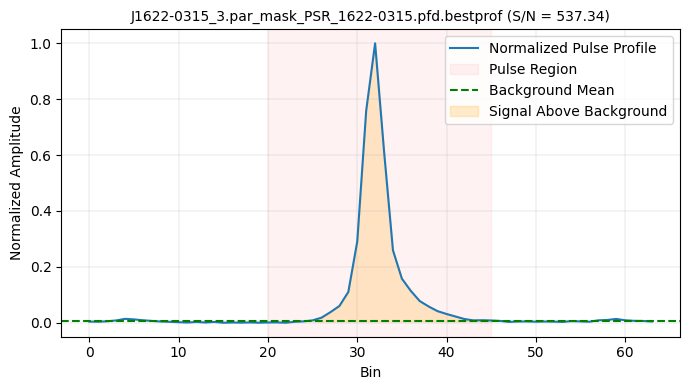

Off-pulse mean (p_off): 13266910263.157894
Off-pulse std (σp): 296625.644295


In [37]:
# Assume you already have the original profile data
# profile = np.array([...])
nbins = len(profile)
# # Shift the peak to the center
peak_bin = np.argmax(profile)
shift = nbins // 2 - peak_bin
profile_aligned = np.roll(profile, shift)
# Simple normalization: Set the minimum value to zero and the maximum value to one.
profile_min = np.min(profile_aligned)
profile_max = np.max(profile_aligned)
profile_normalized = (profile_aligned - profile_min) / (profile_max - profile_min)
# Manually specify the pulse region (based on visualization experience or known parameters)

########################
pulse_region = (20, 45)
########################

pulse_mask = np.zeros(nbins, dtype=bool)
pulse_mask[pulse_region[0]:pulse_region[1]+1] = True
# ===============================
# Handbook-compliant S/N section
# ===============================

# --- off-pulse statistics (USE profile_aligned, NOT normalized)
off_pulse_bins = profile_aligned[~pulse_mask]
p_off = np.mean(off_pulse_bins)
sigma_p = np.std(off_pulse_bins)

# --- equivalent width Weq (Handbook definition)
pulse = profile_aligned[pulse_mask]
pulse_area = np.sum(pulse - p_off)
peak_height = np.max(pulse - p_off)
Weq = pulse_area / peak_height

print(f"Equivalent Width (Weq): {Weq:.2f} bins")

# --- S/N (Equation 7.1 in Lorimer & Kramer 2004)
SNR = (1.0 / (sigma_p * np.sqrt(Weq))) * np.sum(profile_aligned - p_off)
print(f"S/N: {SNR:.2f}")

# NOTE: profile_normalized is used for visualization only.
# All S/N-related quantities are computed from profile_aligned.
# Visualize the combined grap
plt.figure(figsize=(7, 4))
# Plot normalized profile
plt.plot(profile_normalized, label='Normalized Pulse Profile')
# Pulse region
plt.axvspan(pulse_region[0], pulse_region[1],
            color='red', alpha=0.05, label='Pulse Region')

# Normalized background mean
p_off_norm = (p_off - profile_min) / (profile_max - profile_min)
plt.axhline(p_off_norm, color='green', linestyle='--',
            label='Background Mean')

# Fill signal above background (normalized space)
plt.fill_between(
    range(pulse_region[0], pulse_region[1] + 1),
    profile_normalized[pulse_region[0]:pulse_region[1] + 1],
    p_off_norm,
    where=(profile_normalized[pulse_region[0]:pulse_region[1] + 1] > p_off_norm),
    color='orange', alpha=0.2, label='Signal Above Background'
)

plt.title(f"{file_name} (S/N = {SNR:.2f})", fontsize=10)
plt.xlabel("Bin")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True, linewidth=0.2)
plt.tight_layout()
plt.show()

# Output the background statistical information
print(f"Off-pulse mean (p_off): {p_off:.6f}")
print(f"Off-pulse std (σp): {sigma_p:.6f}")

## Radiometric Sensitivity Limits (Lorimer & Kramer 2004; Cordes & McLaughlin 2003)

### Periodic pulsation sensitivity

$$
S_{\mathrm{periodic}}
=
\beta \,
\frac{(S/N)\,T_{\mathrm{sys}}}
{G \sqrt{n_p \, T_{\mathrm{int}} \, \Delta \mathrm{BW}}}
\sqrt{\frac{W_{\mathrm{obs}}}{P - W_{\mathrm{obs}}}},
\tag{1}
$$

which yields the **period-averaged flux density** in units of Jy.

---

### Single-pulse sensitivity

$$
S_{\mathrm{single}}
=
2\beta \,
\frac{(S/N)_{\mathrm{peak}} \, T_{\mathrm{sys}}}
{G \sqrt{n_p \, W_{\mathrm{obs}} \, \Delta \mathrm{BW}}},
\tag{2}
$$

which yields the **peak flux density** of an individual pulse in units of Jy.


---

### Notes

- $ \beta $ : sensitivity degradation factor  
- $ S/N $ : detection threshold signal-to-noise ratio  
- $ (S/N)_{\mathrm{peak}} $ : peak signal-to-noise ratio of a single pulse  
- $ T_{\mathrm{sys}} $ : system temperature  
- $ G $ : telescope gain  
- $ n_p $ : number of summed polarizations  
- $ T_{\mathrm{int}} $ : integration time  
- $ \Delta \mathrm{BW} $ : observing bandwidth  
- $ W_{\mathrm{obs}} $ : observed pulse width  
- $ P $ : pulsar spin period  

In [40]:
import numpy as np
##
def flux_density_periodic(snr, Tsys, G, npol, tint, bandwidth, Wobs, P, beta=1.0):
    """
    Calculate mean flux density of a periodic pulsar (Jy).

    Parameters
    ----------
    snr : float
        Detection S/N threshold
    Tsys : float
        System temperature (K)
    G : float
        Telescope gain (K/Jy)
    npol : int
        Number of polarizations
    tint : float
        Integration time (s)
    bandwidth : float
        Observing bandwidth (Hz)
    Wobs : float
        Observed pulse width (s)
    P : float
        Pulsar period (s)
    beta : float, optional
        Sensitivity degradation factor (default = 1)

    Returns
    -------
    S_periodic : float
        Mean flux density (Jy)
    """
    return beta * snr * Tsys / (G * np.sqrt(npol * tint * bandwidth)) * np.sqrt(Wobs / (P - Wobs))

##
def flux_density_single_pulse(snr_peak, Tsys, G, npol, bandwidth, Wobs, beta=1.0):
    """
    Calculate peak flux density of a single pulse (Jy).

    Parameters
    ----------
    snr_peak : float
        Peak S/N of the pulse
    Tsys : float
        System temperature (K)
    G : float
        Telescope gain (K/Jy)
    npol : int
        Number of polarizations
    bandwidth : float
        Observing bandwidth (Hz)
    Wobs : float
        Observed pulse width (s)
    beta : float, optional
        Sensitivity degradation factor (default = 1)

    Returns
    -------
    S_single : float
        Peak flux density (Jy)
    """
    return 2*beta*snr_peak*Tsys/(G*np.sqrt(npol*Wobs*bandwidth))

In [70]:
# FAST-like parameters
Tsys = 24.0          # K
G = 16.0             # K/Jy
npol = 2
bandwidth = 400e6    # Hz
beta = 1.0

# Periodic pulsar example
snr = 547.0
tint = 380.0        # 30 min
P = 0.003846093              # s
Wobs = (3.60/64)*P         # s

S_per = flux_density_periodic(
    snr, Tsys, G, npol, tint, bandwidth, Wobs, P, beta
)
print(f"Periodic mean flux density: {S_per*1e3:.6f} mJy")

# Single pulse example
snr_peak = 35.5
Wobs_sp = 1e-3*0.5       # 1 ms

S_sp = flux_density_single_pulse(
    snr_peak, Tsys, G, npol, bandwidth, Wobs_sp, beta
)
print(f"Single-pulse peak flux density: {S_sp*1e3:.6f} mJy")
print(f"S_sp / S_per: {(S_sp / S_per):.6f}")


Periodic mean flux density: 0.363308 mJy
Single-pulse peak flux density: 168.391285 mJy
S_sp / S_per: 463.494983


In [74]:
# FAST-like parameters
Tsys = 24.0          # K
G = 16.0             # K/Jy
npol = 2
bandwidth = 400e6    # Hz
beta = 1.0

# Periodic pulsar example
snr = 1114
tint = 5 * 3600        # 30 min
P = 0.003846093              # s
Wobs = (3.60/64)*P         # s

S_per = flux_density_periodic(
    snr, Tsys, G, npol, tint, bandwidth, Wobs, P, beta
)
print(f"Periodic mean flux density: {S_per*1e3:.6f} mJy")

# Single pulse example
snr_peak = 35.5
Wobs_sp = 1e-3*0.5       # 1 ms

S_sp = flux_density_single_pulse(
    snr_peak, Tsys, G, npol, bandwidth, Wobs_sp, beta
)
print(f"Single-pulse peak flux density: {S_sp*1e3:.6f} mJy")
print(f"S_sp / S_per: {(S_sp / S_per):.6f}")


Periodic mean flux density: 0.107505 mJy
Single-pulse peak flux density: 168.391285 mJy
S_sp / S_per: 1566.360156


In [80]:
# FAST-like parameters
Tsys = 24.0          # K
G = 16.0             # K/Jy
npol = 2
bandwidth = 400e6    # Hz
beta = 1.0

# Periodic pulsar example
snr = 1114
tint = 5 * 3600        # 30 min
P = 0.003846093              # s
Wobs = (3.60/64)*P         # s

S_per = flux_density_periodic(
    snr, Tsys, G, npol, tint, bandwidth, Wobs, P, beta
)
print(f"Periodic mean flux density: {S_per*1e3:.6f} mJy")

# Single pulse example
snr_peak = 7
Wobs_sp = 1e-3*0.5       # 1 ms

S_sp = flux_density_single_pulse(
    snr_peak, Tsys, G, npol, bandwidth, Wobs_sp, beta
)
print(f"Single-pulse peak flux density: {S_sp*1e3:.6f} mJy")
print(f"S_sp / S_per: {(S_sp / S_per):.6f}")


Periodic mean flux density: 0.107505 mJy
Single-pulse peak flux density: 33.203915 mJy
S_sp / S_per: 308.859749


In [81]:
(1.2*300)

360.0

In [82]:
0.107505 *300

32.2515